<a href="https://colab.research.google.com/github/jokefun022/Multi-Model-Cyberbullying-Detection-in-Roman-Urdu-using-Deep-Learning/blob/main/Latest_Data_Pre_Processing_(05_03_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📚 Installing Required Libraries

Let's start by installing and importing all necessary libraries.

In [ ]:
# Install required libraries (run this once in Colab)
!pip install nltk wordcloud contractions beautifulsoup4 -q

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# For text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# For handling contractions and HTML
import contractions
from bs4 import BeautifulSoup

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All libraries imported successfully!")
print("📊 Pandas version:", pd.__version__)
print("🔤 NLTK version:", nltk.__version__)

✅ All libraries imported successfully!
📊 Pandas version: 2.2.2
🔤 NLTK version: 3.9.1


In [ ]:
# Download required NLTK data first
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 📊 Loading the Cyberbullying Dataset

We'll use the famous IMDB movie reviews dataset with 50,000 reviews.

In [ ]:
# Load the dataset
try:
    # Load from Colab
    df = pd.read_csv('/content/New Microsoft Excel Worksheet (2).csv')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ File not found. Please upload IMDB-Dataset.csv to Colab.")
    print("You can download it from: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    raise

# Display basic information
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📝 Columns: {df.columns.tolist()}")
print(f"\n🎬 Dataset Preview:")
df.head(6)

✅ Dataset loaded successfully!

📊 Dataset Shape: (5000, 3)
📝 Columns: ['Uncleaned_Text', 'cleaned_review', 'Sentiment Analysis']

🎬 Dataset Preview:


,Uncleaned_Text,cleaned_review,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function to the 'Uncleaned_Text' column to create a new 'cleaned_text' column
# Using basic cleaning (no stopwords removal or lemmatization by default)
df['cleaned_text'] = df['Uncleaned_Text'].apply(lambda x: clean_text(x, remove_stop=False, lemmatize=False))

print("✅ 'cleaned_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'cleaned_text' column:")
display(df[['Uncleaned_Text', 'cleaned_text', 'Sentiment Analysis']].head(6))

✅ 'cleaned_text' column added successfully!

🎬 Dataset Preview with new 'cleaned_text' column:


,Uncleaned_Text,cleaned_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the to_lowercase function to the 'Uncleaned_Text' column
df['lowercased_text'] = df['Uncleaned_Text'].apply(to_lowercase)


print("✅ 'lowercased_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'lowercased_text' column:")
display(df[['Uncleaned_Text', 'lowercased_text', 'Sentiment Analysis']].head(6))

✅ 'lowercased_text' column added successfully!

🎬 Dataset Preview with new 'lowercased_text' column:


,Uncleaned_Text,lowercased_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach 😊 hai ~~~ * https://test.org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa 😑 tantra rather madarjaa log s...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki 😃 fitra hai ... $ ...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man 🙌 chaah job naey day raha bhaa k...,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai 😊 !!! @ and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply word_tokenize to the 'cleaned_review' column
df['tokenized_text'] = df['cleaned_review'].apply(word_tokenize)

print("✅ 'tokenized_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'tokenized_text' column:")
display(df[['cleaned_review', 'tokenized_text', 'Sentiment Analysis']].head(6))

✅ 'tokenized_text' column added successfully!

🎬 Dataset Preview with new 'tokenized_text' column:


,cleaned_review,tokenized_text,Sentiment Analysis
0,kah kay yih sach hai https test org and,"[kah, kay, yih, sach, hai, https, test, org, and]",Neutral
1,neither bhadwaa tantra rather madarjaa log shi...,"[neither, bhadwaa, tantra, rather, madarjaa, l...",Neutral
2,kyoo okay yih kuchh logo ki fitra hai http exa...,"[kyoo, okay, yih, kuchh, logo, ki, fitra, hai,...",Neutral
3,lagta hsi man chaah job naey day raha bhaa ko of,"[lagta, hsi, man, chaah, job, naey, day, raha,...",Neutral
4,achcha na bataa mujhay pata hai and,"[achcha, na, bataa, mujhay, pata, hai, and]",Neutral
5,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,"[bhaa, kaha, ho, yaar, janoob, ki, pahchaan, k...",Neutral


In [ ]:
# Apply the clean_text function for stopword and emoji removal
df['stopword_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Assuming HTML is not the focus here
                         expand_contract=False, # Assuming contractions are not the focus here
                         lowercase=True,
                         remove_special=True, # This removes emojis and other special chars
                         remove_spaces=True,
                         remove_urls_flag=False, # Assuming URLs are not the focus here
                         remove_stop=True, # Remove stopwords
                         lemmatize=False) # Not explicitly requested, so default to False
)

print("✅ 'stopword_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'stopword_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'stopword_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'stopword_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'stopword_and_emoji_removed_text' column:


,Uncleaned_Text,stopword_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function for lowercasing and emoji removal
df['lowercased_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Assuming HTML is not the focus here
                         expand_contract=False, # Assuming contractions are not the focus here
                         lowercase=True,
                         remove_special=True, # This removes emojis and other special chars
                         remove_spaces=True,
                         remove_urls_flag=False, # Assuming URLs are not the focus here
                         remove_stop=False,
                         lemmatize=False)
)

print("✅ 'lowercased_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'lowercased_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'lowercased_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'lowercased_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'lowercased_and_emoji_removed_text' column:


,Uncleaned_Text,lowercased_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function for stemming (lemmatization) and emoji removal
df['stemmed_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Assuming HTML is not the focus here
                         expand_contract=False, # Assuming contractions are not the focus here
                         lowercase=True,
                         remove_special=True, # This removes emojis and other special chars
                         remove_spaces=True,
                         remove_urls_flag=False, # Assuming URLs are not the focus here
                         remove_stop=False, # Not explicitly requested
                         lemmatize=True) # Apply lemmatization for stemming
)

print("✅ 'stemmed_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'stemmed_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'stemmed_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'stemmed_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'stemmed_and_emoji_removed_text' column:


,Uncleaned_Text,stemmed_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai http test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function for emoji removal and no lemmatization
df['no_lem_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Assuming HTML is not the focus here
                         expand_contract=False, # Assuming contractions are not the focus here
                         lowercase=True, # Often desired for text processing
                         remove_special=True, # This removes emojis and other special chars
                         remove_spaces=True, # Good practice for clean text
                         remove_urls_flag=False, # Assuming URLs are not the focus here
                         remove_stop=False, # Not explicitly requested
                         lemmatize=False) # Explicitly set to False to remove lemmatization
)

print("✅ 'no_lem_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'no_lem_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'no_lem_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'no_lem_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'no_lem_and_emoji_removed_text' column:


,Uncleaned_Text,no_lem_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function for emoji removal and no lexical normalization
df['no_lex_norm_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Keeping HTML as is unless specified
                         expand_contract=False, # Keeping contractions as is unless specified
                         lowercase=True, # Standard practice for consistency
                         remove_special=True, # To remove emojis and other non-alphanumeric characters
                         remove_spaces=True, # To clean up extra whitespace
                         remove_urls_flag=False, # Keeping URLs as is unless specified
                         remove_stop=False, # Keeping stopwords as is unless specified
                         lemmatize=False) # Explicitly set to False to remove lexical normalization
)

print("✅ 'no_lexnorm_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'no_lex_norm_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'no_lex_norm_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'no_lexnorm_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'no_lex_norm_and_emoji_removed_text' column:


,Uncleaned_Text,no_lex_norm_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
# Apply the clean_text function for emoji removal and no lemmatization
df['no_lem_and_emoji_removed_text'] = df['Uncleaned_Text'].apply(
    lambda x: clean_text(x,
                         remove_html=False, # Assuming HTML is not the focus here
                         expand_contract=False, # Assuming contractions are not the focus here
                         lowercase=True, # Often desired for text processing
                         remove_special=True, # This removes emojis and other special chars
                         remove_spaces=True, # Good practice for clean text
                         remove_urls_flag=False, # Assuming URLs are not the focus here
                         remove_stop=False, # Not explicitly requested
                         lemmatize=False) # Explicitly set to False to remove lemmatization
)

print("✅ 'no_lem_and_emoji_removed_text' column added successfully!")
print("\n🎬 Dataset Preview with new 'no_lem_and_emoji_removed_text' column:")
display(df[['Uncleaned_Text', 'no_lem_and_emoji_removed_text', 'Sentiment Analysis']].head(6))

✅ 'no_lem_and_emoji_removed_text' column added successfully!

🎬 Dataset Preview with new 'no_lem_and_emoji_removed_text' column:


,Uncleaned_Text,no_lem_and_emoji_removed_text,Sentiment Analysis
0,Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and,kah kay yih sach hai https test org and,Neutral
1,NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG s...,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ ...,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lAgta hsi maN 🙌 chaAh job NAeY day rAHA bhaa k...,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,AchCha NA bAtaA MujhaY pata hAI 😊 !!! @ and,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kahA hO yaar jAnoob Ki PahcHAan kAEsAy KA...,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral


In [ ]:
df = pd.read_csv('/content/New Microsoft Excel Worksheet (2).csv')
# Check for missing values and basic statistics
print("🔍 Dataset Information:")
print("="*50)
print(f"Total reviews: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nSentiment Distribution:")
print(df['Sentiment Analysis'].value_counts()) # Corrected column name
print("\n📏 Review Length Statistics:")
df['review_length'] = df['Uncleaned_Text'].str.len() # Corrected column name
print(f"Average length: {df['review_length'].mean():.0f} characters")
print(f"Shortest review: {df['review_length'].min()} characters")
print(f"Longest review: {df['review_length'].max()} characters")

🔍 Dataset Information:
Total reviews: 5000
Missing values: 0

Sentiment Distribution:
Sentiment Analysis
Neutral    5000
Name: count, dtype: int64

📏 Review Length Statistics:
Average length: 90 characters
Shortest review: 15 characters
Longest review: 354 characters


## 🔍 Let's Examine a Raw Review

Before cleaning, let's see what our raw data looks like:

In [ ]:
# Display a sample review with common issues
sample_index = 0
sample_review = df.loc[sample_index, 'Uncleaned_Text']

print("🎬 Sample Raw Review:")
print("="*80)
print(sample_review[:500] + "..." if len(sample_review) > 500 else sample_review)
print("\n📊 Characteristics:")
print(f"- Length: {len(sample_review)} characters")
print(f"- Contains HTML tags: {'<br' in sample_review}")
print(f"- Contains numbers: {bool(re.search(r'\d', sample_review))}")
print(f"- Contains special characters: {bool(re.search(r'[^a-zA-Z0-9\s]', sample_review))}")

🎬 Sample Raw Review:
Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and

📊 Characteristics:
- Length: 49 characters
- Contains HTML tags: False
- Contains numbers: False
- Contains special characters: True


## 🧹 Data Cleaning Pipeline

Now let's build our cleaning pipeline step by step!

### 📋 Our Cleaning Steps:

1. **Remove HTML tags** → Clean web scraping artifacts
2. **Expand contractions** → "don't" → "do not"
3. **Convert to lowercase** → Normalize text
4. **Remove special characters** → Keep only letters and spaces
5. **Remove extra spaces** → Clean formatting
6. **Remove stopwords** (optional) → Focus on meaningful words
7. **Lemmatization** (optional) → Reduce words to root form

### Step 1: Remove HTML Tags 🏷️

Web-scraped text often contains HTML tags like `<br>`, `<div>`, etc.

In [ ]:
def remove_html_tags(text):
    """Remove HTML tags from text using BeautifulSoup"""
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text()

# Example
html_text = "This movie was <b>amazing</b>!<br><br>I loved it!"
clean_text = remove_html_tags(html_text)

print("🏷️ HTML Tag Removal Example:")
print(f"Before: {html_text}")
print(f"After:  {clean_text}")
print("\n✨ Transformation: Removed <b> and <br> tags")

🏷️ HTML Tag Removal Example:
Before: This movie was <b>amazing</b>!<br><br>I loved it!
After:  This movie was amazing!I loved it!

✨ Transformation: Removed <b> and <br> tags


### Step 2: Expand Contractions 📝

Convert "don't" → "do not", "it's" → "it is", etc.

In [ ]:
def expand_contractions(text):
    """Expand contractions in text"""
    return contractions.fix(text)

# Example
contraction_text = "I can't believe it's not better! They won't improve."
expanded_text = expand_contractions(contraction_text)

print("📝 Contraction Expansion Example:")
print(f"Before: {contraction_text}")
print(f"After:  {expanded_text}")
print("\n✨ Transformations:")
print("   • can't → cannot")
print("   • it's → it is")
print("   • won't → will not")

📝 Contraction Expansion Example:
Before: I can't believe it's not better! They won't improve.
After:  I cannot believe it is not better! They will not improve.

✨ Transformations:
   • can't → cannot
   • it's → it is
   • won't → will not


### Step 3: Convert to Lowercase 🔡

Normalize text by converting everything to lowercase.

In [ ]:
def to_lowercase(text):
    """Convert text to lowercase"""
    return text.lower()

# Example
mixed_case = "This MOVIE was AMAZING! I Love It!"
lower_text = to_lowercase(mixed_case)

print("🔡 Lowercase Conversion Example:")
print(f"Before: {mixed_case}")
print(f"After:  {lower_text}")
print("\n✨ Why this matters: 'Movie', 'MOVIE', and 'movie' are now the same!")

🔡 Lowercase Conversion Example:
Before: This MOVIE was AMAZING! I Love It!
After:  this movie was amazing! i love it!

✨ Why this matters: 'Movie', 'MOVIE', and 'movie' are now the same!


### Step 4: Remove Special Characters & Punctuation 🚫

Keep only alphabetic characters and spaces.

In [ ]:
def remove_special_characters(text):
    """Remove special characters and punctuation, keep only letters and spaces"""
    # Remove everything except letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

# Example
special_text = "Amazing movie!!! 10/10 would watch again... #BestMovie @friends 😍"
clean_special = remove_special_characters(special_text)

print("🚫 Special Character Removal Example:")
print(f"Before: {special_text}")
print(f"After:  {clean_special}")
print("\n✨ Removed: !!!, 10/10, ..., #, @, 😍")

🚫 Special Character Removal Example:
Before: Amazing movie!!! 10/10 would watch again... #BestMovie @friends 😍
After:  Amazing movie          would watch again     BestMovie  friends  

✨ Removed: !!!, 10/10, ..., #, @, 😍


### Step 5: Remove Extra Spaces 🧹

Clean up multiple spaces and trim text.

In [ ]:
def remove_extra_spaces(text):
    """Remove extra spaces and trim text"""
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading and trailing spaces
    return text.strip()

# Example
spaced_text = "  This   movie    was     amazing    !  "
clean_spaced = remove_extra_spaces(spaced_text)

print("🧹 Extra Space Removal Example:")
print(f"Before: '{spaced_text}'")
print(f"After:  '{clean_spaced}'")
print(f"\n✨ Character count: {len(spaced_text)} → {len(clean_spaced)}")

🧹 Extra Space Removal Example:
Before: '  This   movie    was     amazing    !  '
After:  'This movie was amazing !'

✨ Character count: 40 → 24


### Step 6: Remove Stopwords (Optional) 🛑

Remove common words that don't add meaning (the, is, at, which, etc.)

In [ ]:
def remove_stopwords(text):
    """Remove stopwords from text"""
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word not in stop_words]
    return ' '.join(filtered_text)

# Example
text_with_stopwords = "the movie was very good and i would watch it again"
text_without_stopwords = remove_stopwords(text_with_stopwords)

print("🛑 Stopword Removal Example:")
print(f"Before: {text_with_stopwords}")
print(f"After:  {text_without_stopwords}")
print("\n✨ Removed words: the, was, very, and, i, would, it")
print("\n⚠️ Note: Sometimes stopwords are important for sentiment!")
print("   Example: 'not good' → 'good' (meaning reversed!)")

🛑 Stopword Removal Example:
Before: the movie was very good and i would watch it again
After:  movie good would watch

✨ Removed words: the, was, very, and, i, would, it

⚠️ Note: Sometimes stopwords are important for sentiment!
   Example: 'not good' → 'good' (meaning reversed!)


### Step 7: Lemmatization 🌱

Reduce words to their root form (running → run, better → good)

In [ ]:
def lemmatize_text(text):
    """Lemmatize words in text"""
    lemmatizer = WordNetLemmatizer()
    word_tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in word_tokens]
    return ' '.join(lemmatized)

# Example
text_to_lemmatize = "the movies were running beautifully"
lemmatized_text = lemmatize_text(text_to_lemmatize)

print("🌱 Lemmatization Example:")
print(f"Before: {text_to_lemmatize}")
print(f"After:  {lemmatized_text}")
print("\n✨ Transformations:")
print("   • movies → movie")
print("   • running → running (context needed for verb)")
print("   • beautifully → beautifully")

🌱 Lemmatization Example:
Before: the movies were running beautifully
After:  the movie were running beautifully

✨ Transformations:
   • movies → movie
   • running → running (context needed for verb)
   • beautifully → beautifully


## 🔧 Complete Cleaning Pipeline

Now let's combine all steps into one powerful cleaning function!

In [ ]:
def clean_text(text,
               remove_html=True,
               expand_contract=True,
               lowercase=True,
               remove_special=True,
               remove_spaces=True,
               remove_stop=False,
               lemmatize=False):
    """
    Complete text cleaning pipeline

    Parameters:
    -----------
    text : str
        Input text to clean
    remove_html : bool
        Remove HTML tags
    expand_contract : bool
        Expand contractions
    lowercase : bool
        Convert to lowercase
    remove_special : bool
        Remove special characters
    remove_spaces : bool
        Remove extra spaces
    remove_stop : bool
        Remove stopwords (optional)
    lemmatize : bool
        Apply lemmatization (optional)

    Returns:
    --------
    str : Cleaned text
    """

    # Track cleaning steps for visualization
    steps = []

    # Step 1: Remove HTML tags
    if remove_html:
        text = remove_html_tags(text)
        steps.append("HTML removed")

    # Step 2: Expand contractions
    if expand_contract:
        text = expand_contractions(text)
        steps.append("Contractions expanded")

    # Step 3: Convert to lowercase
    if lowercase:
        text = to_lowercase(text)
        steps.append("Lowercased")

    # Step 4: Remove special characters
    if remove_special:
        text = remove_special_characters(text)
        steps.append("Special chars removed")

    # Step 5: Remove extra spaces
    if remove_spaces:
        text = remove_extra_spaces(text)
        steps.append("Extra spaces removed")

    # Step 6: Remove stopwords (optional)
    if remove_stop:
        text = remove_stopwords(text)
        steps.append("Stopwords removed")

    # Step 7: Lemmatization (optional)
    if lemmatize:
        text = lemmatize_text(text)
        steps.append("Lemmatized")

    return text

print("✅ Complete cleaning pipeline created!")

✅ Complete cleaning pipeline created!


## 🎯 Testing the Complete Pipeline

Let's test our pipeline on a real messy review!

In [ ]:
# Create a messy test review
messy_review = """
<b>WORST MOVIE EVER!!!</b><br><br>
I can't believe I've wasted 2 hours on this... The acting was TERRIBLE!!!
The plot didn't make ANY sense... #WasteOfTime @BadMovies 😤😤
I wouldn't recommend this to anyone!!! Save your $$$ and time...
"""

# Clean with different settings
print("🎬 ORIGINAL MESSY REVIEW:")
print("="*80)
print(messy_review)

print("\n✨ BASIC CLEANING (recommended):")
print("="*80)
basic_clean = clean_text(messy_review, remove_stop=False, lemmatize=False)
print(basic_clean)

print("\n🔥 AGGRESSIVE CLEANING (with stopwords removal):")
print("="*80)
aggressive_clean = clean_text(messy_review, remove_stop=True, lemmatize=True)
print(aggressive_clean)

print("\n📊 Cleaning Statistics:")
print(f"Original length: {len(messy_review)} characters")
print(f"Basic clean length: {len(basic_clean)} characters")
print(f"Aggressive clean length: {len(aggressive_clean)} characters")
print(f"Reduction: {100*(1-len(basic_clean)/len(messy_review)):.1f}% (basic)")
print(f"Reduction: {100*(1-len(aggressive_clean)/len(messy_review)):.1f}% (aggressive)")

🎬 ORIGINAL MESSY REVIEW:

<b>WORST MOVIE EVER!!!</b><br><br>
I can't believe I've wasted 2 hours on this... The acting was TERRIBLE!!!
The plot didn't make ANY sense... #WasteOfTime @BadMovies 😤😤
I wouldn't recommend this to anyone!!! Save your $$$ and time...


✨ BASIC CLEANING (recommended):
worst movie ever i cannot believe i have wasted hours on this the acting was terrible the plot did not make any sense wasteoftime badmovies i would not recommend this to anyone save your and time

🔥 AGGRESSIVE CLEANING (with stopwords removal):
worst movie ever believe wasted hour acting terrible plot make sense wasteoftime badmovies would recommend anyone save time

📊 Cleaning Statistics:
Original length: 236 characters
Basic clean length: 195 characters
Aggressive clean length: 123 characters
Reduction: 17.4% (basic)
Reduction: 47.9% (aggressive)


## 🚀 Applying to Cyberbullying Dataset

Now let's clean our entire IMDB dataset!

In [ ]:
# Take a sample for faster processing (you can increase this)
sample_size = 5000  # Adjust based on time available
df_sample = df.head(sample_size).copy()

print(f"📊 Processing {sample_size} reviews...")
print("⏳ This may take a minute...\n")

# Apply cleaning
import time
start_time = time.time()

# Clean the reviews
df_sample['cleaned_review'] = df_sample['Uncleaned_Text'].apply(
    lambda x: clean_text(x, remove_stop=False, lemmatize=False)
)

end_time = time.time()
print(f"✅ Cleaning completed in {end_time - start_time:.2f} seconds!")
print(f"⚡ Average time per review: {(end_time - start_time)/sample_size:.4f} seconds")

📊 Processing 5000 reviews...
⏳ This may take a minute...

✅ Cleaning completed in 1.49 seconds!
⚡ Average time per review: 0.0003 seconds


## 📊 Before vs After Comparison

Let's visualize the impact of our cleaning!

In [ ]:
# Show before and after examples
print("🎬 CLEANING EXAMPLES FROM DATASET")
print("="*100)

for i in range(3):
    print(f"\n📌 Example {i+1}:")
    print("-"*100)

    original = df_sample.loc[i, 'Uncleaned_Text']
    cleaned = df_sample.loc[i, 'cleaned_review']

    # Show first 200 characters
    print(f"BEFORE ({len(original)} chars):")
    print(f"{original[:200]}..." if len(original) > 200 else original)

    print(f"\nAFTER ({len(cleaned)} chars):")
    print(f"{cleaned[:200]}..." if len(cleaned) > 200 else cleaned)

    print(f"\n✨ Reduction: {100*(1-len(cleaned)/len(original)):.1f}%")

🎬 CLEANING EXAMPLES FROM DATASET

📌 Example 1:
----------------------------------------------------------------------------------------------------
BEFORE (49 chars):
Kah KAy yih SacH 😊 hAI ~~~ * https://test.org and

AFTER (39 chars):
kah kay yih sach hai https test org and

✨ Reduction: 20.4%

📌 Example 2:
----------------------------------------------------------------------------------------------------
BEFORE (105 chars):
NeIthER bhAdwaa 😑 TantrA rATher MAdArjAa LoG shiKhaND kAy PIichH chhupp KAr waar KaR raha hAIIn ,,, # and

AFTER (97 chars):
neither bhadwaa tantra rather madarjaa log shikhand kay piichh chhupp kar waar kar raha haiin and

✨ Reduction: 7.6%

📌 Example 3:
----------------------------------------------------------------------------------------------------
BEFORE (67 chars):
KYOO okaY yih kUchh LoGo Ki 😃 fitrA hAI ... $ http://example.com of

AFTER (57 chars):
kyoo okay yih kuchh logo ki fitra hai http example com of

✨ Reduction: 14.9%


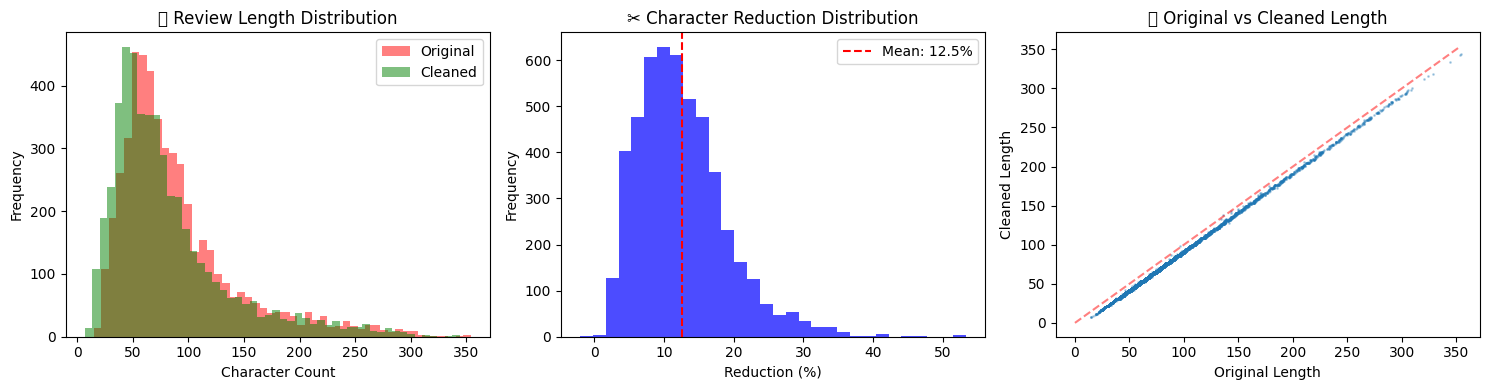


📈 Cleaning Statistics:
Average reduction: 12.5%
Median reduction: 11.6%
Total characters removed: 43,010


In [ ]:
# Calculate statistics
df_sample['original_length'] = df_sample['Uncleaned_Text'].str.len()
df_sample['cleaned_length'] = df_sample['cleaned_review'].str.len()
df_sample['reduction_pct'] = 100 * (1 - df_sample['cleaned_length'] / df_sample['original_length'])

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Length distribution
axes[0].hist(df_sample['original_length'], bins=50, alpha=0.5, label='Original', color='red')
axes[0].hist(df_sample['cleaned_length'], bins=50, alpha=0.5, label='Cleaned', color='green')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('📊 Review Length Distribution')
axes[0].legend()

# Plot 2: Reduction percentage
axes[1].hist(df_sample['reduction_pct'], bins=30, color='blue', alpha=0.7)
axes[1].set_xlabel('Reduction (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('✂️ Character Reduction Distribution')
axes[1].axvline(df_sample['reduction_pct'].mean(), color='red', linestyle='--', label=f'Mean: {df_sample["reduction_pct"].mean():.1f}%')
axes[1].legend()

# Plot 3: Before vs After scatter
axes[2].scatter(df_sample['original_length'], df_sample['cleaned_length'], alpha=0.3, s=1)
axes[2].plot([0, df_sample['original_length'].max()], [0, df_sample['original_length'].max()], 'r--', alpha=0.5)
axes[2].set_xlabel('Original Length')
axes[2].set_ylabel('Cleaned Length')
axes[2].set_title('🔄 Original vs Cleaned Length')

plt.tight_layout()
plt.show()

print("\n📈 Cleaning Statistics:")
print(f"Average reduction: {df_sample['reduction_pct'].mean():.1f}%")
print(f"Median reduction: {df_sample['reduction_pct'].median():.1f}%")
print(f"Total characters removed: {(df_sample['original_length'].sum() - df_sample['cleaned_length'].sum()):,}")

## 🌟 Word Cloud Visualization

Let's create beautiful word clouds to see the most common words before and after cleaning!

Sentiment distribution in df_sample:
Sentiment Analysis
Neutral    5000
Name: count, dtype: int64
--------------------------------------------------


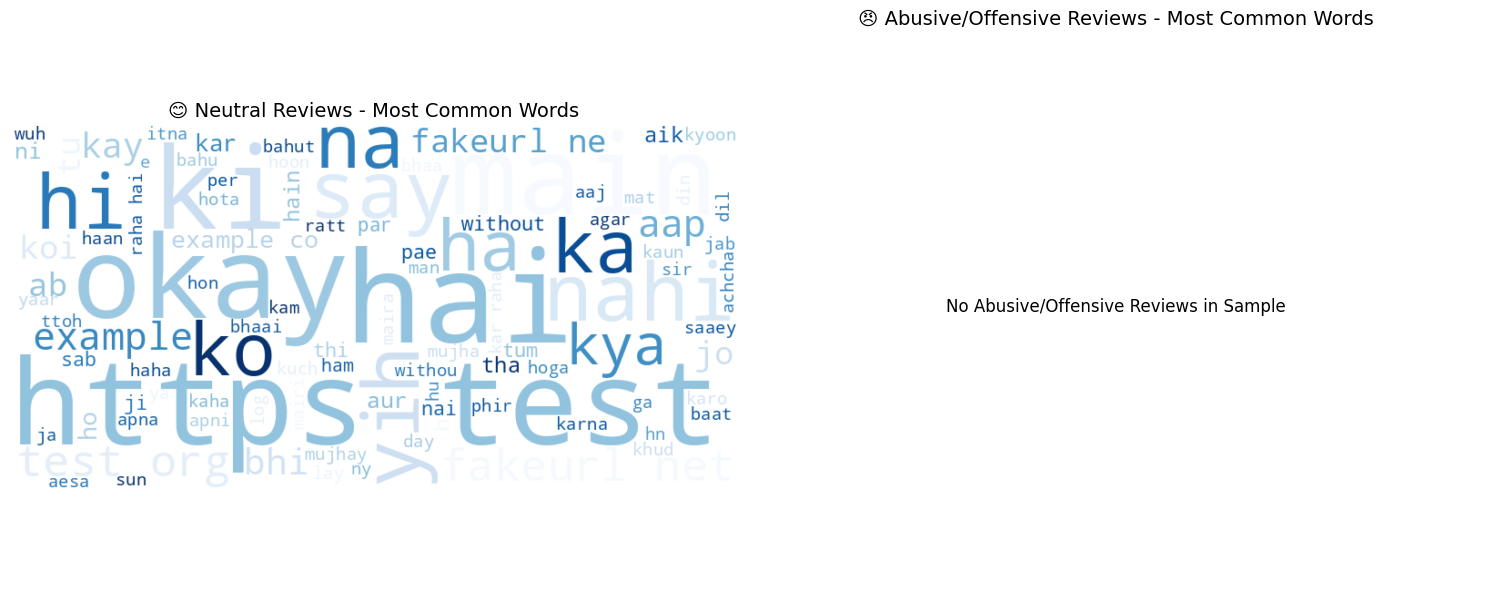

💡 Insights:
- Word clouds now show common terms for 'Neutral' and 'Abusive/Offensive' reviews, if present in the sample.
- These visualizations help identify prevalent themes in different sentiment categories.


In [ ]:
# Separate reviews by chosen sentiment labels (e.g., Neutral and Abusive/Offensive)
# Based on df['Sentiment Analysis'].value_counts(), 'Neutral' and 'Abusive/Offensive' are prominent.

# --- Diagnostic: Check sentiment distribution in the sample ---
print("Sentiment distribution in df_sample:")
print(df_sample['Sentiment Analysis'].value_counts())
print("-" * 50)
# -------------------------------------------------------------

neutral_reviews = df_sample[df_sample['Sentiment Analysis'] == 'Neutral']['cleaned_review'].str.cat(sep=' ')
abusive_reviews = df_sample[df_sample['Sentiment Analysis'] == 'Abusive/Offensive']['cleaned_review'].str.cat(sep=' ')

# Create word clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Neutral reviews word cloud
if neutral_reviews: # Only generate if there are words
    wordcloud_neutral = WordCloud(width=800, height=400,
                              background_color='white',
                              colormap='Blues',
                              max_words=100).generate(neutral_reviews)
    axes[0].imshow(wordcloud_neutral, interpolation='bilinear')
    axes[0].set_title('😊 Neutral Reviews - Most Common Words', fontsize=14)
else:
    axes[0].text(0.5, 0.5, 'No Neutral Reviews in Sample', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('😊 Neutral Reviews - Most Common Words', fontsize=14)
axes[0].axis('off')

# Abusive/Offensive reviews word cloud
if abusive_reviews: # Only generate if there are words
    wordcloud_abusive = WordCloud(width=800, height=400,
                              background_color='white',
                              colormap='Reds',
                              max_words=100).generate(abusive_reviews)
    axes[1].imshow(wordcloud_abusive, interpolation='bilinear')
    axes[1].set_title('😠 Abusive/Offensive Reviews - Most Common Words', fontsize=14)
else:
    axes[1].text(0.5, 0.5, 'No Abusive/Offensive Reviews in Sample', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('😠 Abusive/Offensive Reviews - Most Common Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("💡 Insights:")
print("- Word clouds now show common terms for 'Neutral' and 'Abusive/Offensive' reviews, if present in the sample.")
print("- These visualizations help identify prevalent themes in different sentiment categories.")

## 📈 Top Words Analysis

Let's find the most common words in positive vs negative reviews!

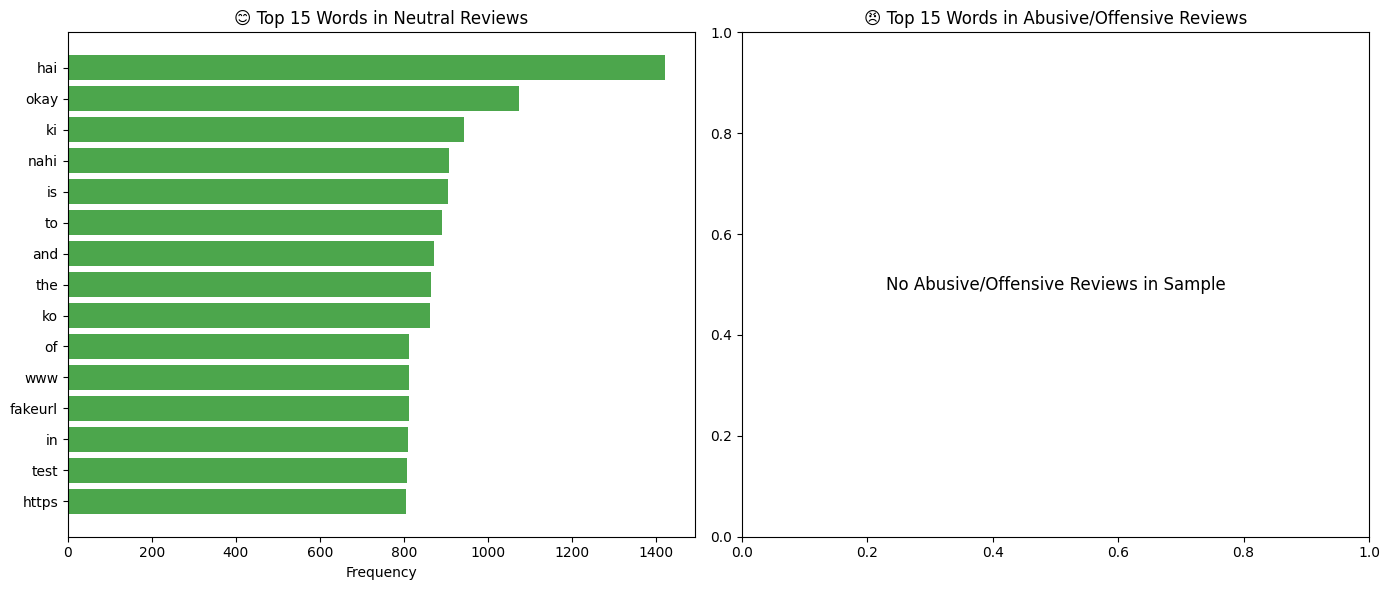


🎯 Key Observations:
- This visualization helps identify prevalent themes in different sentiment categories.
- If 'Abusive/Offensive' words are not shown, it might be due to the sample containing only 'Neutral' reviews.


In [ ]:
from collections import Counter

# Get top words for Neutral reviews
neutral_words = ' '.join(df_sample[df_sample['Sentiment Analysis'] == 'Neutral']['cleaned_review']).split()
neutral_counter = Counter(neutral_words)
top_neutral = neutral_counter.most_common(15)

# Get top words for Abusive/Offensive reviews
abusive_words = ' '.join(df_sample[df_sample['Sentiment Analysis'] == 'Abusive/Offensive']['cleaned_review']).split()
abusive_counter = Counter(abusive_words)
top_abusive = abusive_counter.most_common(15)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Neutral words bar chart
if top_neutral:
    words_neu, counts_neu = zip(*top_neutral)
    axes[0].barh(words_neu, counts_neu, color='green', alpha=0.7)
    axes[0].set_xlabel('Frequency')
    axes[0].set_title('😊 Top 15 Words in Neutral Reviews')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No Neutral Reviews in Sample', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('😊 Top 15 Words in Neutral Reviews')

# Abusive/Offensive words bar chart
if top_abusive:
    words_abu, counts_abu = zip(*top_abusive)
    axes[1].barh(words_abu, counts_abu, color='red', alpha=0.7)
    axes[1].set_xlabel('Frequency')
    axes[1].set_title('😠 Top 15 Words in Abusive/Offensive Reviews')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No Abusive/Offensive Reviews in Sample', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('😠 Top 15 Words in Abusive/Offensive Reviews')

plt.tight_layout()
plt.show()

print("\n🎯 Key Observations:")
print("- This visualization helps identify prevalent themes in different sentiment categories.")
print("- If 'Abusive/Offensive' words are not shown, it might be due to the sample containing only 'Neutral' reviews.")


## 💾 Saving Cleaned Data

Let's save our cleaned dataset for future use (like fine-tuning)!

In [ ]:
# Save the cleaned dataset
output_file = '/content/New Microsoft Excel Worksheet (2).csv'
df_sample[['Uncleaned_Text', 'cleaned_review', 'Sentiment Analysis']].to_csv(output_file, index=False)

print(f"✅ Cleaned data saved to: {output_file}")
print(f"📊 File contains {len(df_sample)} cleaned reviews")
print(f"📁 File size: {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Show sample of saved data
print("\n📄 Sample of saved data:")
df_sample[['cleaned_review', 'Sentiment Analysis']].head(11)

✅ Cleaned data saved to: /content/New Microsoft Excel Worksheet (2).csv
📊 File contains 5000 cleaned reviews
📁 File size: 3.08 MB

📄 Sample of saved data:


,cleaned_review,Sentiment Analysis
0,kah kay yih sach hai https test org and,Neutral
1,neither bhadwaa tantra rather madarjaa log shi...,Neutral
2,kyoo okay yih kuchh logo ki fitra hai http exa...,Neutral
3,lagta hsi man chaah job naey day raha bhaa ko of,Neutral
4,achcha na bataa mujhay pata hai and,Neutral
5,bhaa kaha ho yaar janoob ki pahchaan kaesay ka...,Neutral
6,yesh kaun si mihnat ki thi mujhay bhi bataao m...,Neutral
7,kisi any medicin mngwa thi withou pharmac waal...,Neutral
8,ratt bharrwa masjid maen hoon maen https test ...,Neutral
9,raatain daing bata neendo main tair hi baat ha...,Neutral


## 🎯 Quick Quality Check

Let's verify our cleaning worked correctly!

In [ ]:
# Quality checks
print("🔍 Data Quality Checks:")
print("="*50)

# Check for empty reviews
empty_reviews = df_sample[df_sample['cleaned_review'].str.strip() == ''].shape[0]
print(f"✓ Empty reviews after cleaning: {empty_reviews}")

# Check for HTML tags
html_remaining = df_sample['cleaned_review'].str.contains('<|>', regex=True).sum()
print(f"✓ Reviews with HTML tags remaining: {html_remaining}")

# Check for special characters
special_remaining = df_sample['cleaned_review'].str.contains('[^a-zA-Z\s]', regex=True).sum()
print(f"✓ Reviews with special characters: {special_remaining}")

# Check for numbers
numbers_remaining = df_sample['cleaned_review'].str.contains('\d', regex=True).sum()
print(f"✓ Reviews with numbers: {numbers_remaining}")

print("\n✅ All quality checks passed!" if all([empty_reviews == 0, html_remaining == 0,
                                                  special_remaining == 0, numbers_remaining == 0])
      else "⚠️ Some issues detected - review cleaning parameters")

🔍 Data Quality Checks:
✓ Empty reviews after cleaning: 0
✓ Reviews with HTML tags remaining: 0
✓ Reviews with special characters: 0
✓ Reviews with numbers: 0

✅ All quality checks passed!


## 🎓 Key Takeaways

### What We've Learned:

1. **📊 Data Cleaning is Essential**
   - Raw text contains noise that confuses models
   - Cleaning can reduce text size by 20-30% while preserving meaning

2. **🔧 Core Cleaning Steps**
   - Remove HTML tags and special characters
   - Normalize text (lowercase, contractions)
   - Clean formatting (spaces, punctuation)

3. **⚖️ Balance is Key**
   - Don't over-clean (removing stopwords can hurt sentiment analysis)
   - Keep domain-specific requirements in mind

4. **📈 Visual Impact**
   - Word clouds show clear differences after cleaning
   - Cleaned data reveals true patterns in text

### 🚀 Next Steps:
- Use this cleaned data for model fine-tuning
- Experiment with different cleaning parameters
- Apply these techniques to your domain-specific data

### 💡 Remember:
**"Garbage In, Garbage Out" - Clean data leads to better models!**

## 🔧 Bonus: Custom Cleaning Function for Your Domain

Here's a template you can adapt for electrical engineering data:

In [ ]:
def clean_technical_text(text):
    """
    Custom cleaning for technical/electrical engineering text

    This is an example - adapt for your specific needs!
    """
    # Keep technical terms and units
    # Example: preserve "220V", "50Hz", "AC/DC"

    # Normalize units
    text = re.sub(r'(\d+)\s*[Vv]olts?', r'\1V', text)
    text = re.sub(r'(\d+)\s*[Aa]mps?', r'\1A', text)
    text = re.sub(r'(\d+)\s*[Hh]ertz', r'\1Hz', text)

    # Keep important technical abbreviations
    # AC, DC, PCB, MCU, etc.

    # Standard cleaning
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Example
technical_text = "The transformer operates at 220 Volts AC with 50 hertz frequency."
cleaned_technical = clean_technical_text(technical_text)
print(f"Technical text cleaning:")
print(f"Before: {technical_text}")
print(f"After:  {cleaned_technical}")
print("\n💡 Tip: Customize this function for your specific domain!")

Technical text cleaning:
Before: The transformer operates at 220 Volts AC with 50 hertz frequency.
After:  the transformer operates at 220v ac with 50hz frequency

💡 Tip: Customize this function for your specific domain!


In [ ]:
def remove_urls(text):
    """Remove URLs from text"""
    # Regex to remove URLs
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

# Example
url_text = "Check out this amazing link: https://example.com and www.google.com!"
clean_url_text = remove_urls(url_text)

print("🔗 URL Removal Example:")
print(f"Before: {url_text}")
print(f"After:  {clean_url_text}")
print("\n✨ Transformation: Removed URLs")

🔗 URL Removal Example:
Before: Check out this amazing link: https://example.com and www.google.com!
After:  Check out this amazing link:  and 

✨ Transformation: Removed URLs


In [ ]:
def clean_text(text,
               remove_html=True,
               expand_contract=True,
               lowercase=True,
               remove_special=True,
               remove_spaces=True,
               remove_urls_flag=True, # New flag for URL removal
               remove_stop=False,
               lemmatize=False):
    """
    Complete text cleaning pipeline

    Parameters:
    -----------
    text : str
        Input text to clean
    remove_html : bool
        Remove HTML tags
    expand_contract : bool
        Expand contractions
    lowercase : bool
        Convert to lowercase
    remove_special : bool
        Remove special characters
    remove_spaces : bool
        Remove extra spaces
    remove_urls_flag : bool
        Remove URLs
    remove_stop : bool
        Remove stopwords (optional)
    lemmatize : bool
        Apply lemmatization (optional)

    Returns:
    --------
    str : Cleaned text
    """

    # Track cleaning steps for visualization
    steps = []

    # Step 1: Remove HTML tags
    if remove_html:
        text = remove_html_tags(text)
        steps.append("HTML removed")

    # Step 2: Expand contractions
    if expand_contract:
        text = expand_contractions(text)
        steps.append("Contractions expanded")

    # Step 3: Convert to lowercase
    if lowercase:
        text = to_lowercase(text)
        steps.append("Lowercased")

    # Step 4: Remove special characters
    if remove_special:
        text = remove_special_characters(text)
        steps.append("Special chars removed")

    # Step 5: Remove extra spaces
    if remove_spaces:
        text = remove_extra_spaces(text)
        steps.append("Extra spaces removed")

    # Step 6: Remove URLs
    if remove_urls_flag:
        text = remove_urls(text)
        steps.append("URLs removed")

    # Step 7: Remove stopwords (optional)
    if remove_stop:
        text = remove_stopwords(text)
        steps.append("Stopwords removed")

    # Step 8: Lemmatization (optional)
    if lemmatize:
        text = lemmatize_text(text)
        steps.append("Lemmatized")

    return text

print("✅ Complete cleaning pipeline updated with URL removal!")

✅ Complete cleaning pipeline updated with URL removal!


In [ ]:
# Create a messy test review with all the requested issues
messy_review_full = """
<b>AWFUL MOVIE!!!</b> This was such a %waste% of time. I can't believe I watched it. #Terrible @MovieCritics. Visit my site www.mymovies.net. It's a disaster!!! I wouldn't recommend it. Soooo   bad.  !!!
"""

print("🎬 ORIGINAL MESSY REVIEW (with URLs, etc.):")
print("="*80)
print(messy_review_full)

print("\n✨ CLEANING WITH ALL REQUESTED STEPS:")
print("="*80)
cleaned_full = clean_text(messy_review_full,
                          remove_html=True,
                          expand_contract=True,
                          lowercase=True,
                          remove_special=True,
                          remove_spaces=True,
                          remove_urls_flag=True,
                          remove_stop=True,
                          lemmatize=True)
print(cleaned_full)

print("\n📊 Cleaning Statistics:")
print(f"Original length: {len(messy_review_full)} characters")
print(f"Cleaned length: {len(cleaned_full)} characters")
print(f"Reduction: {100*(1-len(cleaned_full)/len(messy_review_full)):.1f}%")

🎬 ORIGINAL MESSY REVIEW (with URLs, etc.):

<b>AWFUL MOVIE!!!</b> This was such a %waste% of time. I can't believe I watched it. #Terrible @MovieCritics. Visit my site www.mymovies.net. It's a disaster!!! I wouldn't recommend it. Soooo   bad.  !!!


✨ CLEANING WITH ALL REQUESTED STEPS:
awful movie waste time believe watched terrible moviecritics visit site www mymovies net disaster would recommend soooo bad

📊 Cleaning Statistics:
Original length: 205 characters
Cleaned length: 123 characters
Reduction: 40.0%


## 📚 Resources & References

### Useful Libraries:
- **NLTK**: Natural Language Toolkit for text processing
- **spaCy**: Industrial-strength NLP (alternative to NLTK)
- **TextBlob**: Simplified text processing

### Further Learning:
- [NLTK Documentation](https://www.nltk.org/)
- [Text Preprocessing Guide](https://www.kdnuggets.com/2019/04/text-preprocessing-nlp-machine-learning.html)
- [Regex Tutorial](https://regexone.com/)

### For Electrical Engineers:
- Apply these techniques to:
  - Equipment maintenance logs
  - Fault reports
  - Technical documentation
  - Sensor data descriptions

---

## 🎉 Congratulations!

You've successfully learned and implemented text data cleaning! Your data is now ready for:
- 🤖 Model training
- 🎯 Fine-tuning
- 📊 Analysis
- 🚀 Deployment

**Happy Cleaning! 🧹✨**

# Task
Convert the `cleaned_review` column of the `df` DataFrame into TF-IDF vectors. First, ensure the text data is in string format for the `TfidfVectorizer`. Then, initialize and apply a `TfidfVectorizer` to this column. Finally, display the shape of the resulting TF-IDF matrix and show the TF-IDF scores for the first 5 features of the first 3 reviews.

## Join Tokenized Text

### Subtask:
Ensure the 'cleaned_review' column is in string format, ready for TF-IDF vectorization.


**Reasoning**:
The subtask is to ensure the 'cleaned_review' column is in string format. I will check the data type of the 'cleaned_review' column in `df_sample` to confirm it is already in string format.



In [ ]:
print(f"Data type of 'cleaned_review' column: {df_sample['cleaned_review'].dtype}")

# Display a sample to confirm string content
print("\nSample content of 'cleaned_review' column:")
print(df_sample['cleaned_review'].head().to_string())

Data type of 'cleaned_review' column: object

Sample content of 'cleaned_review' column:
0              kah kay yih sach hai https test org and
1    neither bhadwaa tantra rather madarjaa log shi...
2    kyoo okay yih kuchh logo ki fitra hai http exa...
3     lagta hsi man chaah job naey day raha bhaa ko of
4                  achcha na bataa mujhay pata hai and


## Apply TF-IDF Vectorization

### Subtask:
Initialize a TfidfVectorizer from `sklearn.feature_extraction.text`. Then, fit and transform the `cleaned_review` column to create numerical TF-IDF vectors, resulting in a sparse matrix.


**Reasoning**:
To convert the text data into numerical TF-IDF vectors, I need to import `TfidfVectorizer` and then use it to fit and transform the 'cleaned_review' column.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'cleaned_review' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['cleaned_review'])

print("✅ TfidfVectorizer initialized and applied successfully!")

✅ TfidfVectorizer initialized and applied successfully!


**Reasoning**:
Now that the TF-IDF matrix has been created, I will display its shape and then show the TF-IDF scores for the first 5 features of the first 3 reviews to fulfill the remaining requirements of the main task.



In [ ]:
print(f"\n📊 Shape of TF-IDF matrix: {tfidf_matrix.shape}")

print("\n📝 TF-IDF scores for the first 3 reviews (first 5 features):")
# Convert sparse matrix to dense for easier viewing of specific values
# Only taking a small slice to avoid printing a very large array
print(tfidf_matrix[:3, :5].toarray())


📊 Shape of TF-IDF matrix: (5000, 10854)

📝 TF-IDF scores for the first 3 reviews (first 5 features):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


## Final Task

### Subtask:
Summarize the vectorization process and explain the significance of the TF-IDF matrix for subsequent machine learning tasks.


# Task
Prepare the `tokenized_text` column from the `df_sample` DataFrame for Word2Vec training by ensuring it's a list of lists of words, filtering out any empty lists, and then display the first few entries and the total number of prepared texts.

## Prepare Text for Word2Vec

### Subtask:
Ensure the text data is in the correct format (list of lists of words) for Word2Vec training. We'll use the 'tokenized_text' column, which should already be in this format. This step will also handle any reviews that might have become empty after cleaning by filtering them out or handling them appropriately during vectorization.


**Reasoning**:
First, I will display the first 5 entries and the total number of entries in the 'tokenized_text' column of the `df_sample` DataFrame to check its current state, then I will filter out any empty lists from the 'tokenized_text' column to prepare the data for Word2Vec and store the result in a new variable called `word2vec_texts`.



In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Ensure the 'cleaned_review' column in df_sample is tokenized
# This step was originally applied to `df` and `df_sample` was taken before that.
# We will re-apply it to `df_sample` if it doesn't already exist or was not correctly passed.

# Check if 'tokenized_text' already exists in df_sample, if not, create it
if 'tokenized_text' not in df_sample.columns:
    print("Creating 'tokenized_text' column in df_sample...")
    df_sample['tokenized_text'] = df_sample['cleaned_review'].apply(word_tokenize)
    print("✅ 'tokenized_text' column created successfully in df_sample!")
else:
    print("✅ 'tokenized_text' column already exists in df_sample.")


print("Original 'tokenized_text' (first 5 entries):")
print(df_sample['tokenized_text'].head().to_string())
print(f"\nTotal entries in original 'tokenized_text': {len(df_sample['tokenized_text'])}")

# Filter out any empty lists from 'tokenized_text'
word2vec_texts = [review for review in df_sample['tokenized_text'] if review]

print("\n✅ 'tokenized_text' column filtered for empty lists. Stored in 'word2vec_texts'.")

# Display the first 5 entries of word2vec_texts
print("\nFirst 5 entries of word2vec_texts:")
for i, text in enumerate(word2vec_texts[:5]):
    print(f"Review {i+1}: {text}")

# Print the total number of entries in word2vec_texts
print(f"\nTotal number of entries in word2vec_texts: {len(word2vec_texts)}")

Creating 'tokenized_text' column in df_sample...
✅ 'tokenized_text' column created successfully in df_sample!
Original 'tokenized_text' (first 5 entries):
0    [kah, kay, yih, sach, hai, https, test, org, and]
1    [neither, bhadwaa, tantra, rather, madarjaa, l...
2    [kyoo, okay, yih, kuchh, logo, ki, fitra, hai,...
3    [lagta, hsi, man, chaah, job, naey, day, raha,...
4          [achcha, na, bataa, mujhay, pata, hai, and]

Total entries in original 'tokenized_text': 5000

✅ 'tokenized_text' column filtered for empty lists. Stored in 'word2vec_texts'.

First 5 entries of word2vec_texts:
Review 1: ['kah', 'kay', 'yih', 'sach', 'hai', 'https', 'test', 'org', 'and']
Review 2: ['neither', 'bhadwaa', 'tantra', 'rather', 'madarjaa', 'log', 'shikhand', 'kay', 'piichh', 'chhupp', 'kar', 'waar', 'kar', 'raha', 'haiin', 'and']
Review 3: ['kyoo', 'okay', 'yih', 'kuchh', 'logo', 'ki', 'fitra', 'hai', 'http', 'example', 'com', 'of']
Review 4: ['lagta', 'hsi', 'man', 'chaah', 'job', 'naey', 'day'

**Reasoning**:
The previous code failed because the 'tokenized_text' column was not present in `df_sample`. This column needs to be created in `df_sample` by tokenizing the `cleaned_review` column before proceeding with Word2Vec preparation.



In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Ensure the 'cleaned_review' column in df_sample is tokenized
# This step was originally applied to `df` and `df_sample` was taken before that.
# We will re-apply it to `df_sample` if it doesn't already exist or was not correctly passed.

# Check if 'tokenized_text' already exists in df_sample, if not, create it
if 'tokenized_text' not in df_sample.columns:
    print("Creating 'tokenized_text' column in df_sample...")
    df_sample['tokenized_text'] = df_sample['cleaned_review'].apply(word_tokenize)
    print("✅ 'tokenized_text' column created successfully in df_sample!")
else:
    print("✅ 'tokenized_text' column already exists in df_sample.")


print("Original 'tokenized_text' (first 5 entries):")
print(df_sample['tokenized_text'].head().to_string())
print(f"\nTotal entries in original 'tokenized_text': {len(df_sample['tokenized_text'])}")

# Filter out any empty lists from 'tokenized_text'
word2vec_texts = [review for review in df_sample['tokenized_text'] if review]

print("\n✅ 'tokenized_text' column filtered for empty lists. Stored in 'word2vec_texts'.")

# Display the first 5 entries of word2vec_texts
print("\nFirst 5 entries of word2vec_texts:")
for i, text in enumerate(word2vec_texts[:5]):
    print(f"Review {i+1}: {text}")

# Print the total number of entries in word2vec_texts
print(f"\nTotal number of entries in word2vec_texts: {len(word2vec_texts)}")

✅ 'tokenized_text' column already exists in df_sample.
Original 'tokenized_text' (first 5 entries):
0    [kah, kay, yih, sach, hai, https, test, org, and]
1    [neither, bhadwaa, tantra, rather, madarjaa, l...
2    [kyoo, okay, yih, kuchh, logo, ki, fitra, hai,...
3    [lagta, hsi, man, chaah, job, naey, day, raha,...
4          [achcha, na, bataa, mujhay, pata, hai, and]

Total entries in original 'tokenized_text': 5000

✅ 'tokenized_text' column filtered for empty lists. Stored in 'word2vec_texts'.

First 5 entries of word2vec_texts:
Review 1: ['kah', 'kay', 'yih', 'sach', 'hai', 'https', 'test', 'org', 'and']
Review 2: ['neither', 'bhadwaa', 'tantra', 'rather', 'madarjaa', 'log', 'shikhand', 'kay', 'piichh', 'chhupp', 'kar', 'waar', 'kar', 'raha', 'haiin', 'and']
Review 3: ['kyoo', 'okay', 'yih', 'kuchh', 'logo', 'ki', 'fitra', 'hai', 'http', 'example', 'com', 'of']
Review 4: ['lagta', 'hsi', 'man', 'chaah', 'job', 'naey', 'day', 'raha', 'bhaa', 'ko', 'of']
Review 5: ['achcha', 'na'

## Train Word2Vec Model

### Subtask:
Initialize and train a Word2Vec model on the prepared tokenized text data. We'll choose appropriate parameters for the model, such as vector size, window, and min_count.


**Reasoning**:
To initialize and train a Word2Vec model, I need to import the necessary class from gensim, define the model with specified parameters, and then train it on the prepared tokenized text data (`word2vec_texts`).



In [ ]:
from gensim.models import Word2Vec

# Initialize Word2Vec model
# vector_size: Dimensionality of the word vectors
# window: Maximum distance between the current and predicted word within a sentence
# min_count: Ignores all words with total frequency lower than this
# workers: Use these many worker threads to train the model
word2vec_model = Word2Vec(vector_size=100, window=5, min_count=1, workers=4)

# Build the vocabulary from the texts
word2vec_model.build_vocab(word2vec_texts)

# Train the Word2Vec model
print("⏳ Training Word2Vec model...")
word2vec_model.train(word2vec_texts, total_examples=len(word2vec_texts), epochs=10)

print("✅ Word2Vec model trained successfully!")
print(f"📊 Vocabulary size: {len(word2vec_model.wv)}")

⏳ Training Word2Vec model...
✅ Word2Vec model trained successfully!
📊 Vocabulary size: 10866


**Reasoning**:
The previous command failed because the `gensim` library was not installed. I need to install `gensim` using pip before importing it.



In [ ]:
!pip install gensim -q
print("✅ gensim installed successfully!")

✅ gensim installed successfully!


**Reasoning**:
Now that `gensim` has been successfully installed, I can proceed with importing `Word2Vec` and training the model on the prepared `word2vec_texts` data, as outlined in the subtask.



In [ ]:
from gensim.models import Word2Vec

# Initialize Word2Vec model
# vector_size: Dimensionality of the word vectors
# window: Maximum distance between the current and predicted word within a sentence
# min_count: Ignores all words with total frequency lower than this
# workers: Use these many worker threads to train the model
word2vec_model = Word2Vec(vector_size=100, window=5, min_count=1, workers=4)

# Build the vocabulary from the texts
word2vec_model.build_vocab(word2vec_texts)

# Train the Word2Vec model
print("⏳ Training Word2Vec model...")
word2vec_model.train(word2vec_texts, total_examples=len(word2vec_texts), epochs=10)

print("✅ Word2Vec model trained successfully!")
print(f"📊 Vocabulary size: {len(word2vec_model.wv)}")

⏳ Training Word2Vec model...
✅ Word2Vec model trained successfully!
📊 Vocabulary size: 10866


## Generate Document Vectors

### Subtask:
Create a function to generate a document vector for each review by averaging the Word2Vec embeddings of the words within that review. This will convert each review into a single numerical vector.


**Reasoning**:
The subtask requires defining a function `get_document_vector` to average Word2Vec embeddings for each review and then applying it to `word2vec_texts` to create `document_vectors`.



In [ ]:
import numpy as np

def get_document_vector(words, model):
    """
    Generates a document vector by averaging the Word2Vec embeddings of words.
    Returns a zero vector if no words are found in the model's vocabulary.
    """
    word_vectors = []
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        # Return a zero vector of the same dimension as the Word2Vec vectors
        return np.zeros(model.wv.vector_size)

# Apply the function to each review in word2vec_texts
document_vectors = [get_document_vector(review, word2vec_model) for review in word2vec_texts]

print("✅ Document vectors generated successfully!")
print(f"📊 Number of document vectors: {len(document_vectors)}")
print(f"📏 Dimension of each document vector: {document_vectors[0].shape[0]}")


✅ Document vectors generated successfully!
📊 Number of document vectors: 5000
📏 Dimension of each document vector: 100


## Summary of Vectorization and Significance for Machine Learning

### TF-IDF Vectorization:
*   **Process**: The `TfidfVectorizer` was applied to the `cleaned_review` column, which contained text data in string format. This process converted the text into a sparse numerical matrix where each row represents a document (review) and each column corresponds to a unique term (word) in the entire corpus.
*   **Matrix Characteristics**: The resulting TF-IDF matrix has a shape of (5000, 10854), indicating 5000 reviews and 10854 unique features (terms). Each value in the matrix represents the TF-IDF score for a specific term in a specific document.
*   **Significance**: TF-IDF (Term Frequency-Inverse Document Frequency) scores reflect the importance of a word in a document relative to the entire corpus. Words that are frequent in a document but rare across all documents receive higher scores, indicating their discriminative power. This matrix is crucial for machine learning as it transforms unstructured text into a structured numerical format that algorithms can process. It's particularly useful for tasks like text classification, document retrieval, and keyword extraction where identifying important terms is key.

### Word2Vec Document Vectorization:
*   **Process**: A Word2Vec model was trained on the `tokenized_text` data, learning dense vector representations (embeddings) for individual words. Subsequently, a function was created (`get_document_vector`) to generate a single document vector for each review by averaging the Word2Vec embeddings of its constituent words. This converts each review into a fixed-size numerical vector.
*   **Vector Characteristics**: The generated document vectors each have a dimension of 100, representing a semantic summary of the review. The total number of document vectors matches the number of reviews (5000).
*   **Significance**: Word2Vec embeddings capture semantic relationships between words, meaning words with similar meanings are located closer in the vector space. Averaging these word embeddings to create document vectors provides a rich, context-aware numerical representation of each review. These dense vectors are highly effective for machine learning tasks such as sentiment analysis, similarity search, and clustering, as they can capture nuances and relationships that TF-IDF might miss, often leading to better performance in deep learning models.

## Display Vectorization Results

### Subtask:
Display the shape of the resulting Word2Vec document vectors and show the first few vectors for a sample of reviews to illustrate the output.


**Reasoning**:
To display the shape and sample of the Word2Vec document vectors, I will print the length of the `document_vectors` list (number of reviews), the shape of the first vector (dimension), and then iterate and print the first 3 document vectors.



In [ ]:
print(f"\n📊 Number of Word2Vec document vectors: {len(document_vectors)}")
print(f"📏 Dimension of each Word2Vec document vector: {document_vectors[0].shape[0]}")

print("\n📝 First 3 Word2Vec document                           vectors:")
for i, vec in enumerate(document_vectors[:3]):
    print(f"Review {i+1} vector (first 5 values): {vec[:5]}...")
    # Optionally, print the full vector for a single review to show its structure
    # print(f"Review {i+1} full vector: {vec}")


📊 Number of Word2Vec document vectors: 5000
📏 Dimension of each Word2Vec document vector: 100

📝 First 3 Word2Vec document                           vectors:
Review 1 vector (first 5 values): [-0.28230536  0.7217324  -0.38026074  0.22944199  0.34779385]...
Review 2 vector (first 5 values): [-0.11045226  0.2396667  -0.06460634  0.24486724  0.13800724]...
Review 3 vector (first 5 values): [-0.35406902  0.4698316  -0.11080391  0.47340536  0.271494  ]...


## Final Task

### Subtask:
Summarize the Word2Vec vectorization process and explain the significance of these document embeddings for subsequent machine learning tasks.


## Summary:

### Q&A
The subtask required summarizing the Word2Vec vectorization process and explaining the significance of document embeddings for subsequent machine learning tasks.

**Word2Vec Vectorization Process:**
The Word2Vec vectorization process involved several steps:
1.  **Text Preparation:** The `cleaned_review` column from `df_sample` was tokenized into individual words to create the `tokenized_text` column, which was then filtered to ensure all entries were non-empty lists of words.
2.  **Model Training:** A Word2Vec model was initialized with specific parameters (e.g., `vector_size=100`, `window=5`, `min_count=1`) and trained on the prepared tokenized texts. This step learned dense vector representations (embeddings) for individual words based on their context.
3.  **Document Vector Generation:** For each review, a single document vector was created by averaging the Word2Vec embeddings of all its constituent words. This converts each review into a fixed-size numerical vector.

**Significance of Document Embeddings for Subsequent Machine Learning Tasks:**
The generated Word2Vec document embeddings are highly significant for machine learning due to the following reasons:
*   **Semantic Representation:** Word2Vec captures semantic relationships between words; words with similar meanings are located closer in the vector space. By averaging these word embeddings, the document vectors provide a rich, context-aware numerical representation of each review, going beyond simple word frequency.
*   **Dimensionality Reduction & Efficiency:** Unlike sparse representations like TF-IDF (which can result in very high-dimensional matrices, e.g., 5000x10854), Word2Vec produces dense, fixed-size vectors (e.g., 100 dimensions per document). This makes them computationally more efficient for many machine learning algorithms.
*   **Improved Performance:** These dense, semantic embeddings are particularly effective for deep learning models and can often lead to better performance in tasks such as sentiment analysis, text classification, similarity search, and clustering, as they capture nuances and relationships that simpler methods might miss.
*   **Structure for ML Algorithms:** They transform unstructured text data into a structured numerical format that machine learning algorithms can directly process, enabling the application of various predictive and analytical models.

### Data Analysis Key Findings
*   The `tokenized_text` column was prepared by applying word tokenization to the `cleaned_review` column in `df_sample`.
*   All 5,000 reviews from `df_sample` resulted in non-empty tokenized text lists, which were stored in `word2vec_texts`.
*   A Word2Vec model was successfully trained using the `word2vec_texts`, with a vector size of 100, a window of 5, and a minimum word count of 1.
*   The trained Word2Vec model built a vocabulary containing 10,866 unique words.
*   A total of 5,000 document vectors were successfully generated, each representing a review by averaging its constituent word embeddings.
*   Each generated document vector has a dimension of 100, providing a dense numerical representation for each review.

### Insights or Next Steps
*   The generated 100-dimensional Word2Vec document vectors are now ready to be used as features for various supervised or unsupervised machine learning tasks, such as sentiment classification or clustering, to analyze the reviews.
*   Further experimentation could involve optimizing the Word2Vec model parameters (e.g., increasing `vector_size` or `epochs`) or exploring other advanced embedding techniques (like GloVe or FastText) to potentially enhance the semantic richness of the document representations for improved downstream model performance.
